# Coursework Notebook: 24C0C131 - Data Mining and Machine Learning

## Q0: Necessary Imports

In [ ]:
import numpy as np
import os
from PIL import Image
from coc131_cw import COC131
import matplotlib.pyplot as plt
 

## Q1: Load Dataset


Here we:

 -  Created our class instance which we would use throughout the notebook

 - Loaded the data to speed up processing in the later steps.

 - Lowered the image resolution to 32x32

- Loaded dataset variables self.x for samples and self.y for labels

In [2]:
data_mining = COC131()

x, y = data_mining.q1()
print(x.shape, y.shape)

(27000, 3072) (27000,)


## Q2: Standardize Dataset and Visualise Impact

Here we: 

 - Standardize our dataset from a given input, scaled to a standard deviation of 2.5

 - Visualise the impact of standardization on the dataset

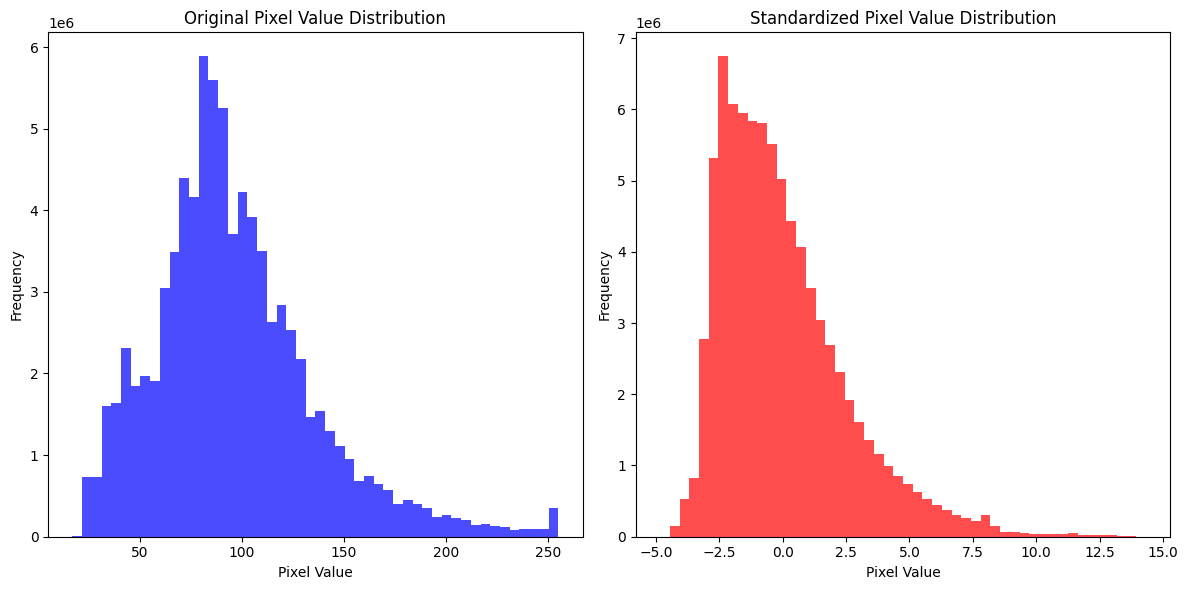

In [3]:
import matplotlib.pyplot as plt


standardized_x, scaler = data_mining.q2(x)

original_pixel = x[:, 0]  
standardized_pixel = standardized_x[:, 0] 

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(x.flatten(), bins=50, color='blue', alpha=0.7, label='Original')
plt.title("Original Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(standardized_x.flatten(), bins=50, color='red', alpha=0.7, label='Standardized')
plt.title("Standardized Pixel Value Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


To show the impact of standardizing the image data. I had plotted two histograms where the one on the left is **before** the standardization process and the one on the second is **after** the process

From this we were able to deduce that:

 - The distribution maintains shape

 - Scaling does not distort the data but adjusts the feature scale for learning

## Q3: Build a MLP Classifier

Here we: 

 - Build a MLP Classifier using the dataset we loaded in Q1

 - We train the classifier using multiple different setups through changing our hyperparameters. Hyperparameters we used were:

 - Use a 70/30 split for our Train/Test sets

 - Track model performance over epochs to find optimal hyperparameters

Hyperparameters we used were:

 - 'hidden_layer_sizes' - Amount of hidden nodes

 - 'learning_rate_init'  - Learning rate schedule for weight updates

 - 'alpha' - Strength of L2 Regularization term

 - 'solver' - Solver for weight optimisation

 - 'activation' - Activation function for the hidden layer

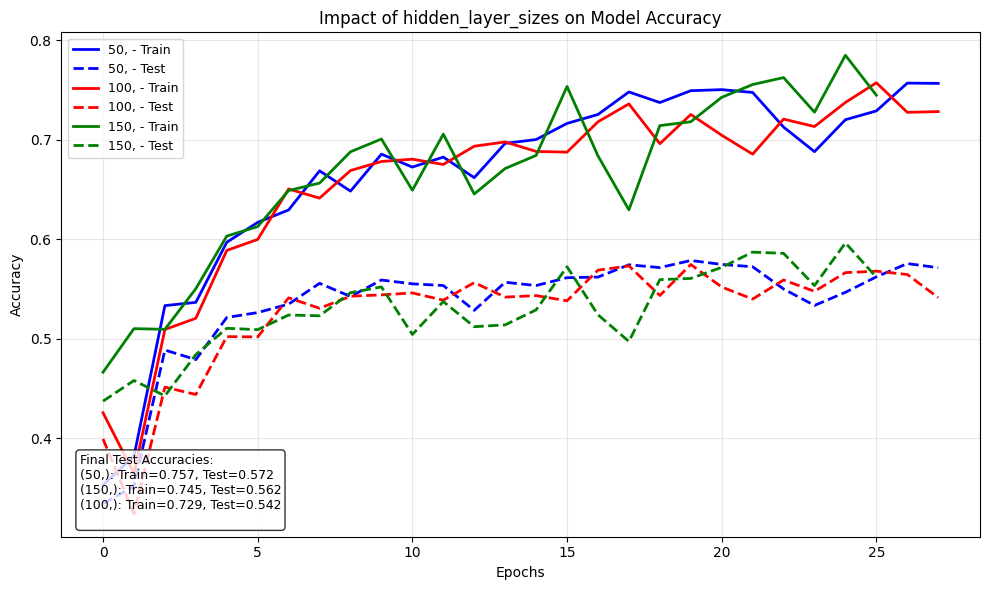

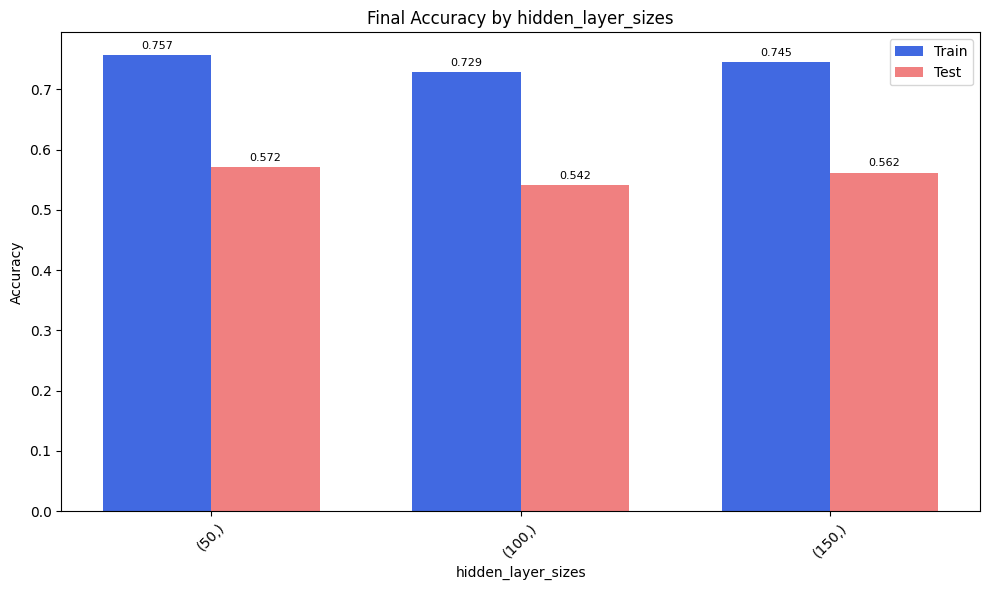

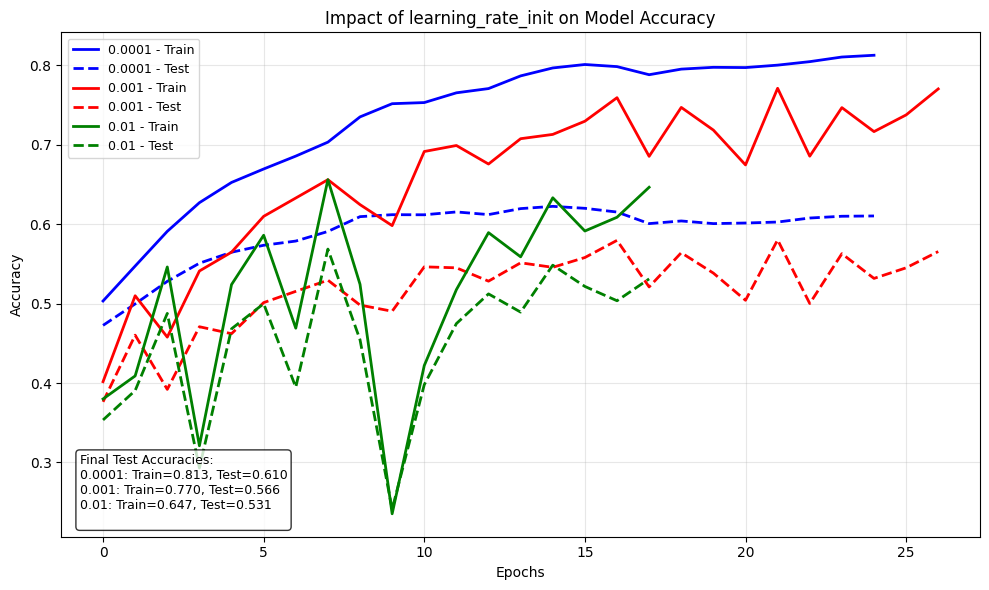

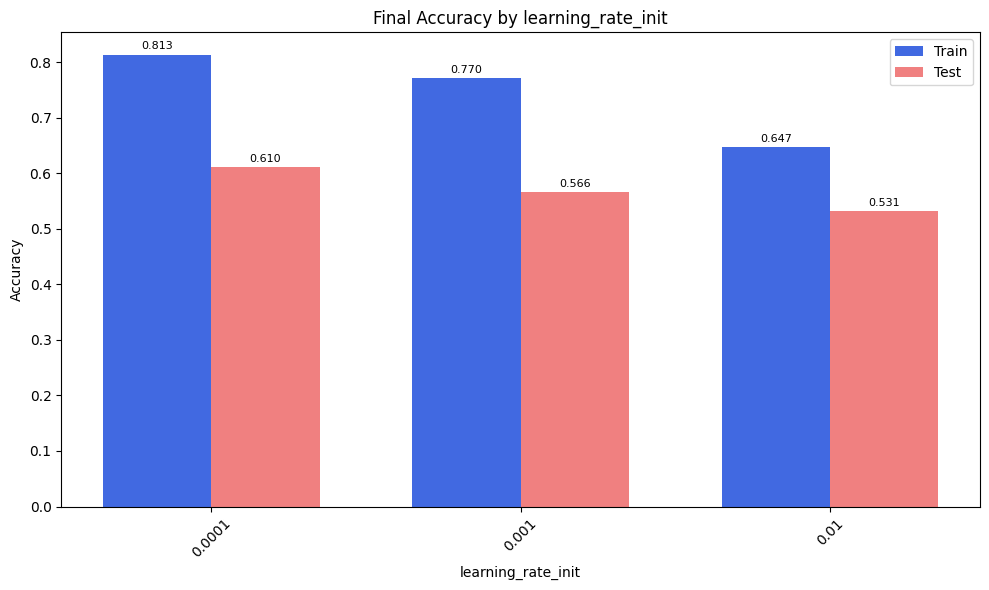

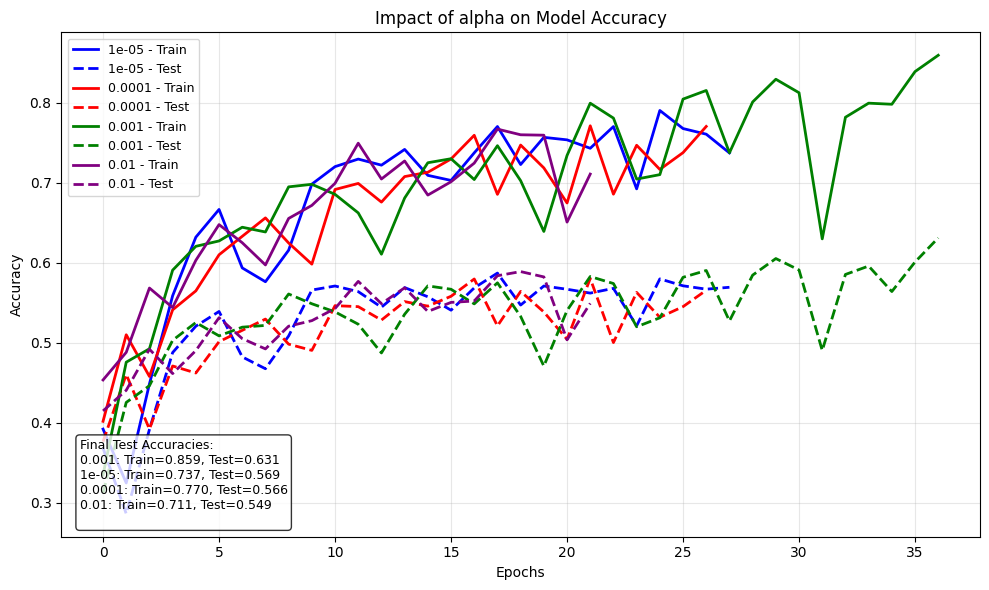

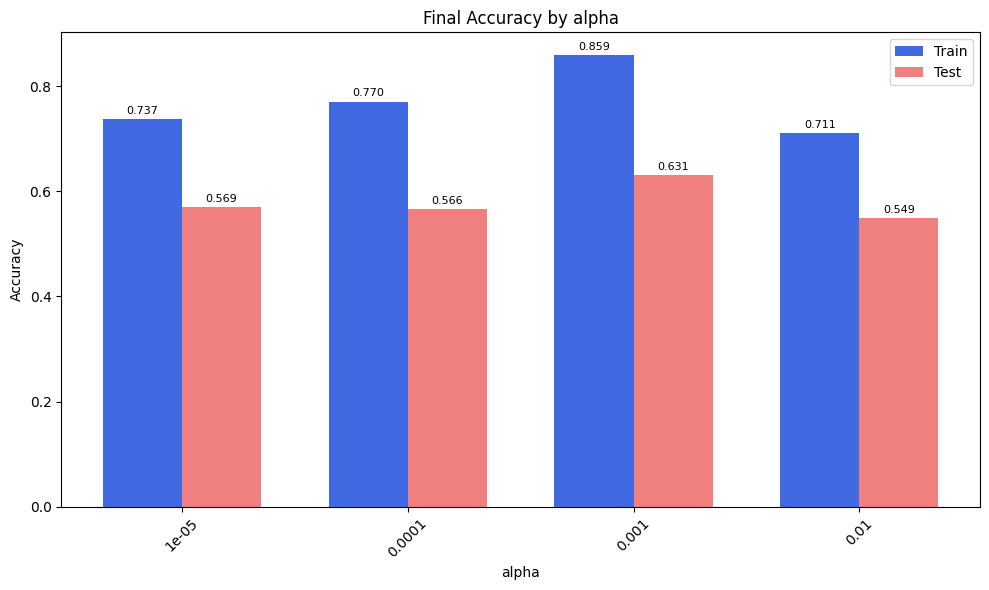

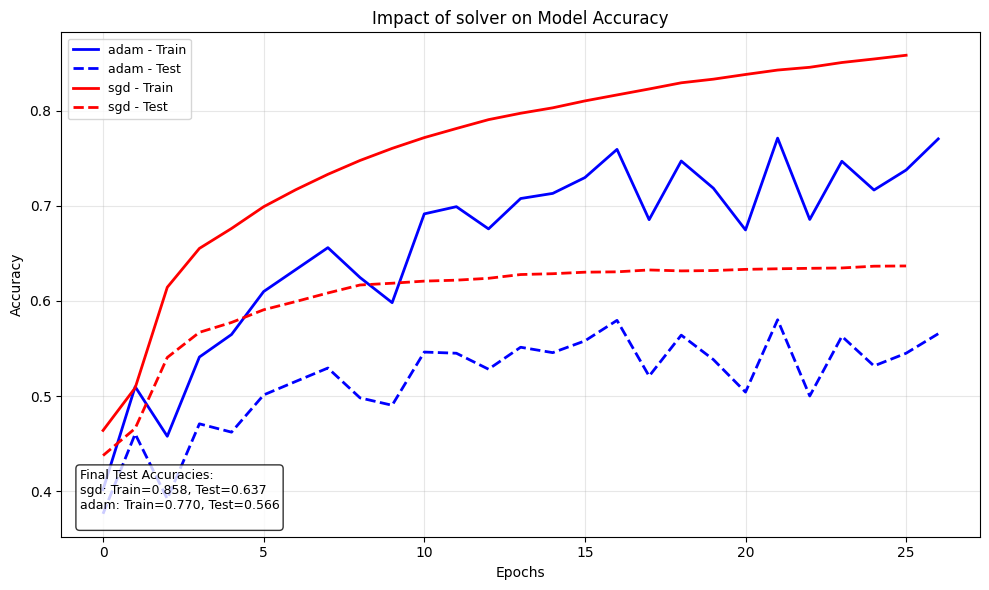

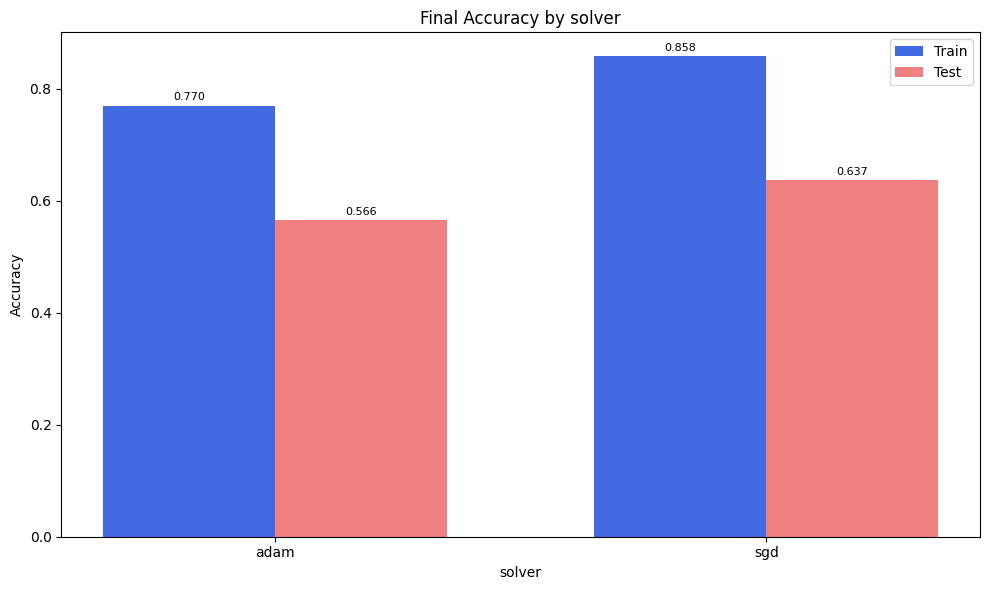

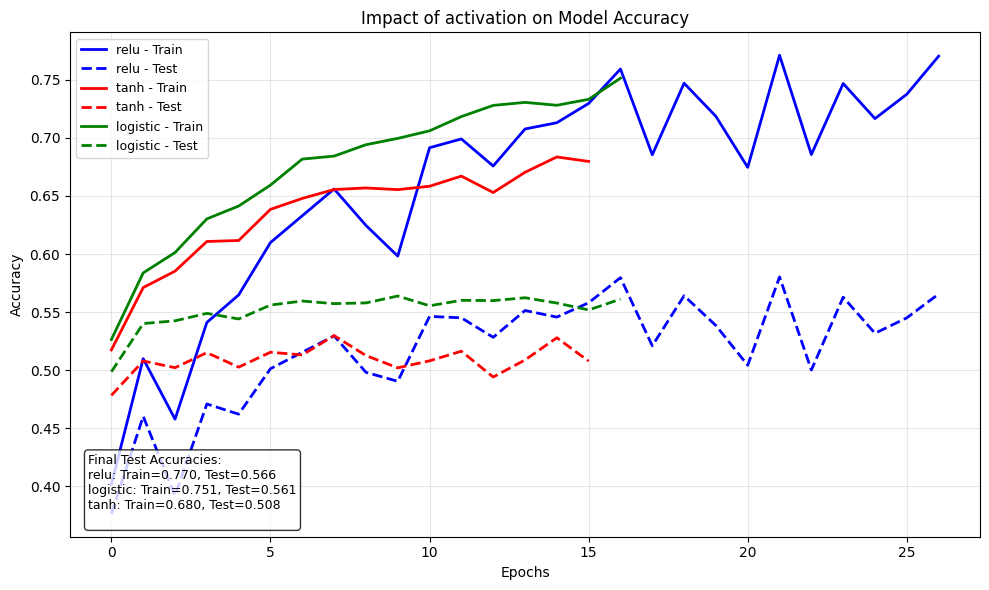

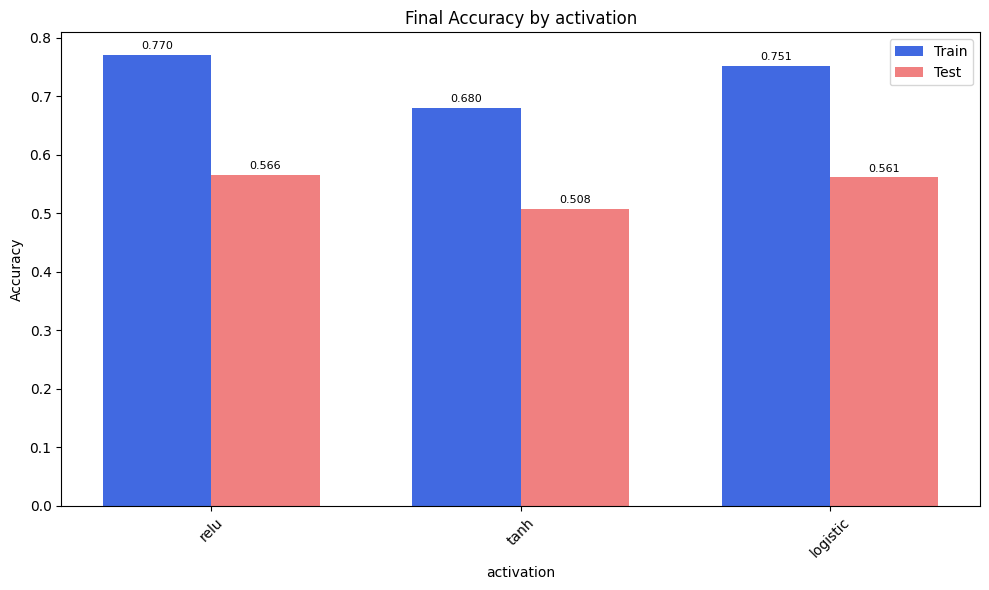

In [ ]:
import matplotlib.pyplot as plt

model, loss_c, train_c, test_c = data_mining.q3(hyperparam={
    'hidden_layer_sizes': [(50,), (100,), (150,)],
    'learning_rate_init': [1e-4, 1e-3, 1e-2],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'solver': ['adam', 'sgd'],  # Only stochastic solvers
    'activation': ['relu', 'tanh', 'logistic']
})

# colours for different parameter values
colors = ['blue', 'red', 'green', 'purple', 'orange', 'cyan', 'magenta', 'olive', 'gray', 'brown']

for param_name, param_runs in data_mining.q3_runs.items():
    plt.figure(figsize=(10, 6))
    
    for i, (param_value, loss_curve, train_curve, test_curve) in enumerate(param_runs):
        color = colors[i % len(colors)]
        
        if isinstance(param_value, tuple):
            label = str(param_value).replace(',)', ',)').replace('(', '').replace(')', '')
        else:
            label = str(param_value)
            
        plt.plot(train_curve, color=color, linestyle='-', linewidth=2, 
                 label=f'{label} - Train')
                 
        plt.plot(test_curve, color=color, linestyle='--', linewidth=2, 
                 label=f'{label} - Test')
    
    plt.title(f'Impact of {param_name} on Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=9)
    
    # add final accuracies to the plot 
    final_accs = [(str(val), tr[-1], te[-1]) 
                  for val, _, tr, te in param_runs]
    final_accs.sort(key=lambda x: x[2], reverse=True)
    
    acc_text = "Final Test Accuracies:\n"
    for val, tr, te in final_accs:
        acc_text += f"{val}: Train={tr:.3f}, Test={te:.3f}\n"
        
    plt.text(0.02, 0.02, acc_text, transform=plt.gca().transAxes,
             va='bottom', fontsize=9, bbox=dict(boxstyle='round',
             facecolor='white', alpha=0.8))
             
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    param_values = [str(val[0]) for val in param_runs]
    x_pos = np.arange(len(param_values))
    width = 0.35
    
    train_accs = [tr[-1] for _, _, tr, _ in param_runs]
    test_accs = [te[-1] for _, _, _, te in param_runs]
    
    plt.bar(x_pos - width/2, train_accs, width, label='Train', color='royalblue')
    plt.bar(x_pos + width/2, test_accs, width, label='Test', color='lightcoral')
    
    plt.xlabel(f'{param_name}')
    plt.ylabel('Accuracy')
    plt.title(f'Final Accuracy by {param_name}')
    plt.xticks(x_pos, param_values, rotation=45 if len(max(param_values, key=len)) > 5 else 0)
    
    for i, v in enumerate(train_accs):
        plt.text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
    for i, v in enumerate(test_accs):
        plt.text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
        
    plt.legend()
    plt.tight_layout()
    plt.show()

From the results we are able to find our best model by checking which parameter values benefit the accuracy the most

Best Parameters:

 - 'hidden_layer_sizes' - 50

 - 'learning_rate_init' - 0.0001

- 'activation' - relu

 - 'alpha' - 0.001

 - 'solver' - sgd

Worst Parameters:

 - 'hidden_layer_sizes' - 100

 - 'learning_rate_init' - 0.01

 - 'activation' - tanh

 - 'alpha' - 0.01

 - 'solver' - adam

Although these parameters show that they are the most beneficial, it does not mean that they together will produce the best result

c:\Users\Bakri\OneDrive - Loughborough University\Data Mining\dm_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


<Figure size 1000x800 with 0 Axes>

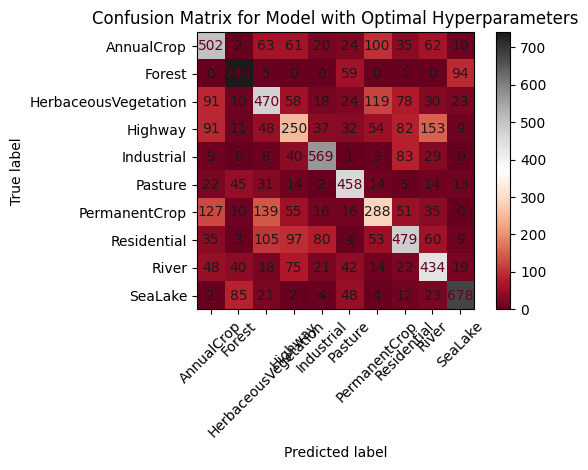

Test accuracy: 0.6010

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.54      0.57      0.56       879
              Forest       0.78      0.82      0.80       899
HerbaceousVegetation       0.52      0.51      0.51       921
             Highway       0.38      0.33      0.35       767
          Industrial       0.74      0.77      0.75       742
             Pasture       0.65      0.74      0.69       618
       PermanentCrop       0.44      0.39      0.42       737
         Residential       0.56      0.52      0.54       925
               River       0.52      0.59      0.55       733
             SeaLake       0.79      0.77      0.78       879

            accuracy                           0.60      8100
           macro avg       0.59      0.60      0.60      8100
        weighted avg       0.60      0.60      0.60      8100



In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# decided to add this part to the code as I thought it would be a good metric to show
# since I already had the optimal hyperparameters from the previous part of the code
# I had just used them instead of running the model again to find them

optimal_hyperparam = {
    'hidden_layer_sizes': (50,),
    'learning_rate_init': 0.0001,
    'activation': 'relu',
    'solver': 'sgd',
    'alpha': 0.001,
    'random_state': 42,
    'max_iter': 200
}

data_mining.x, data_mining.y = standardized_x, y  

X_train, X_test, y_train, y_test = train_test_split(
    data_mining.x, data_mining.y, test_size=0.3, random_state=42)

model = MLPClassifier(**optimal_hyperparam)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(data_mining.y))
disp.plot(cmap='RdGy', values_format='d', xticks_rotation=45)
plt.title('Confusion Matrix for Model with Optimal Hyperparameters')
plt.tight_layout()
plt.show()

accuracy = model.score(X_test, y_test)
print(f"Test accuracy: {accuracy:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Above is a confusion matrix trained with our best set

Allows us to sport patterns between similar land use catogories

Since diagonal elements are light shows model was accurate

Good at predicting forest

## Q4: Study the Effect of Alpha

Here we: 

 - Study the impact of alpha on the performance and parameters of the model based on the alpha values given

In [ ]:
import matplotlib.pyplot as plt

data_mining.x, data_mining.y = standardized_x, y
results = data_mining.q4()

print("Alphas:\n",       results['alphas'])
print("Weight norms:\n", results['weight_norms'])
print("Bias norms:\n",   results['bias_norms'])
print("Train accs:\n",   results['train_accs'])
print("Test accs:\n",    results['test_accs'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# weight norms vs alpha
axes[0, 0].semilogx(results['alphas'][1:], results['weight_norms'][1:], 'o-')
axes[0, 0].set_title("Weight Norms vs Alpha")
axes[0, 0].set_xlabel("Alpha (log scale)")
axes[0, 0].set_ylabel("Weight Norm")
axes[0, 0].grid(True)

# bias norms vs alpha
axes[0, 1].semilogx(results['alphas'][1:], results['bias_norms'][1:], 'o-')
axes[0, 1].set_title("Bias Norms vs Alpha")
axes[0, 1].set_xlabel("Alpha (log scale)")
axes[0, 1].set_ylabel("Bias Norm")
axes[0, 1].grid(True)

# training accuracy vs alpha
axes[1, 0].semilogx(results['alphas'][1:], results['train_accs'][1:], 'o-')
axes[1, 0].set_title("Training Accuracy vs Alpha")
axes[1, 0].set_xlabel("Alpha (log scale)")
axes[1, 0].set_ylabel("Training Accuracy")
axes[1, 0].grid(True)

# testing accuracy vs alpha 
axes[1, 1].semilogx(results['alphas'][1:], results['test_accs'][1:], 'o-')
axes[1, 1].set_title("Testing Accuracy vs Alpha")
axes[1, 1].set_xlabel("Alpha (log scale)")
axes[1, 1].set_ylabel("Testing Accuracy")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# relationship between alpha and the weight/bias norms and accuracies
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.semilogx(results['alphas'][1:], results['weight_norms'][1:], 'o-', label='Weight norm')
plt.semilogx(results['alphas'][1:], results['bias_norms'][1:], 's--', label='Bias norm')
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('L2 Norm')
plt.title('Parameter Norms vs Regularization')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogx(results['alphas'][1:], results['train_accs'][1:], 'o-', label='Train accuracy')
plt.semilogx(results['alphas'][1:], results['test_accs'][1:], 's--', label='Test accuracy')
plt.xlabel('Alpha (regularization strength)')
plt.ylabel('Accuracy')
plt.title('Model Performance vs Regularization')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



c:\Users\Bakri\OneDrive - Loughborough University\Data Mining\dm_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


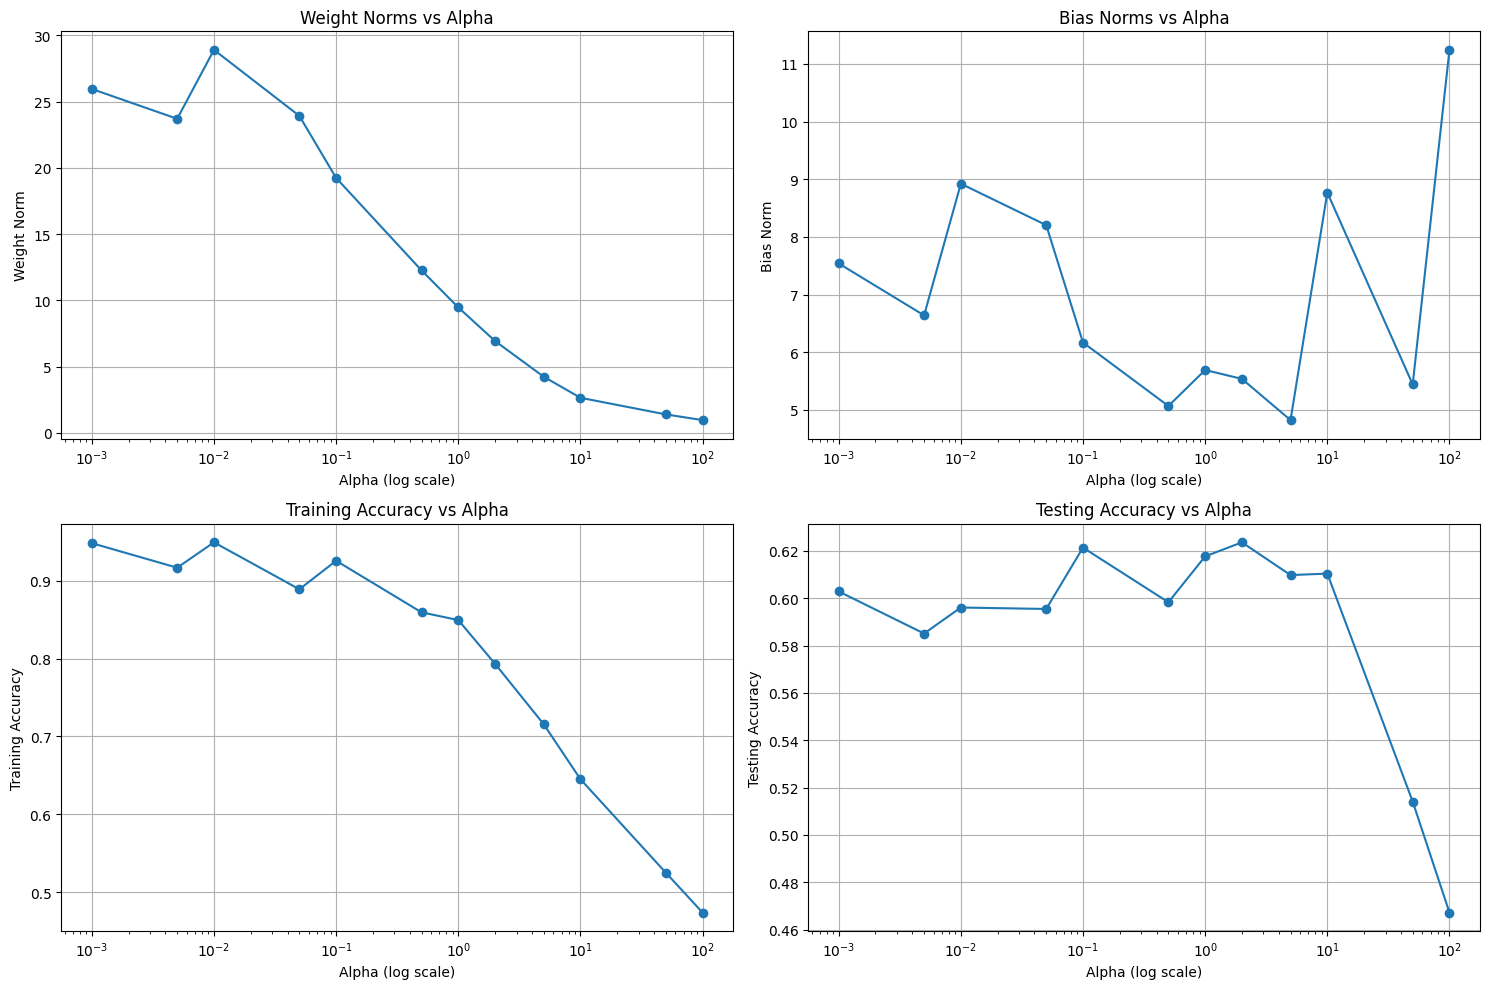

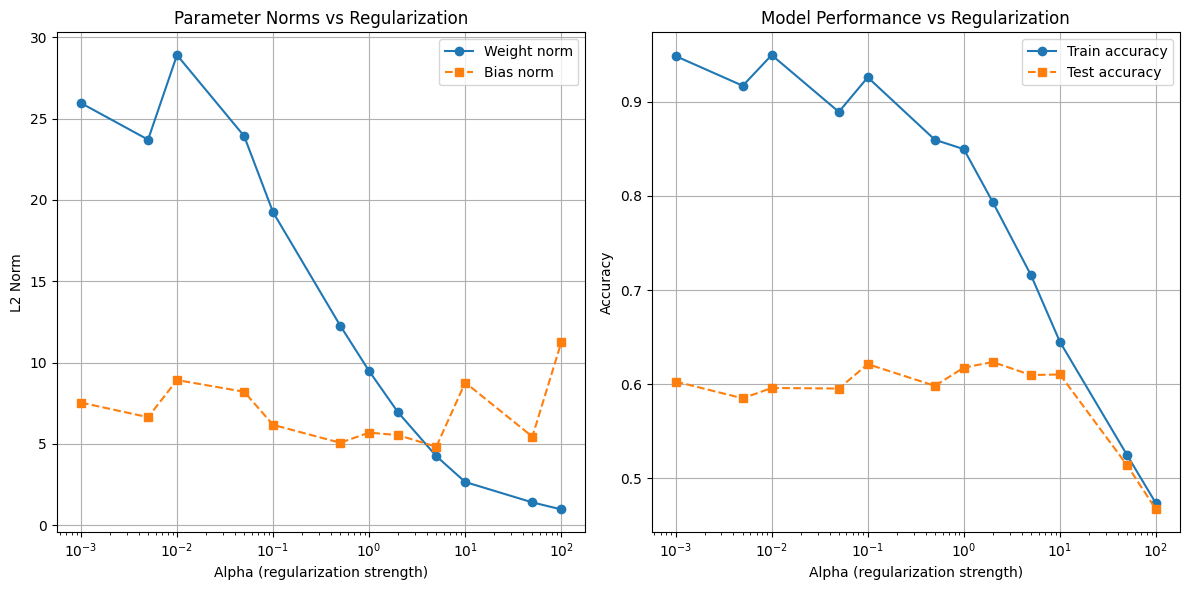

What we can deduce:

 - A large alpha does not benefit large weights as much as small weights

 - A bigger alpha can prevent overfitting

 - This suggests that it may be beneficial to use a **moderate** value

 - Biases are less effected by alpha

 - Higher Regularization leads to smaller weights

## Q5: Hypothesis Testing to Compare Effect of CV

Here we: 

 - Use hypothesis testing to study the impact of using CV with and without Stratification on the performance of MLPClassifier

 - Perform 5-Fold CV on dataset using both methods

 - Visualise accuracy distribution and mean 

c:\Users\Bakri\OneDrive - Loughborough University\Data Mining\dm_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Bakri\OneDrive - Loughborough University\Data Mining\dm_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Bakri\OneDrive - Loughborough University\Data Mining\dm_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\Bakri\OneDrive - Loughborough University\Data Mining\dm_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimi

Plain CV scores:      [0.52166667 0.51833333 0.53648148 0.51925926 0.51407407]
Stratified CV scores: [0.52       0.52185185 0.52111111 0.52574074 0.51185185]
p-value: 0.6472913644245473
Conclusion: Splitting method had no effect


C:\Users\Bakri\AppData\Local\Temp\ipykernel_12856\4181409579.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([plain, strat], labels=['Plain','Stratified'])


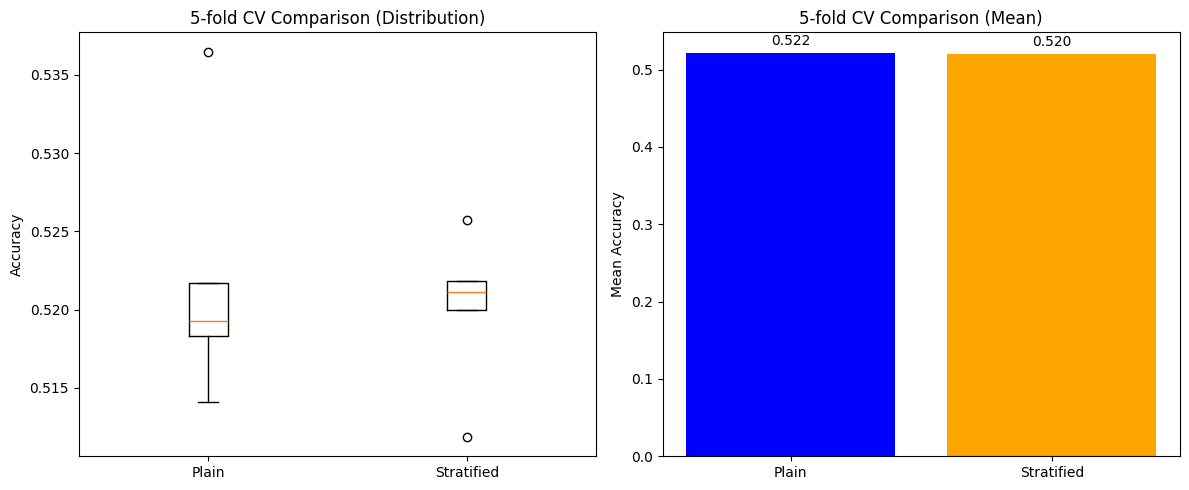

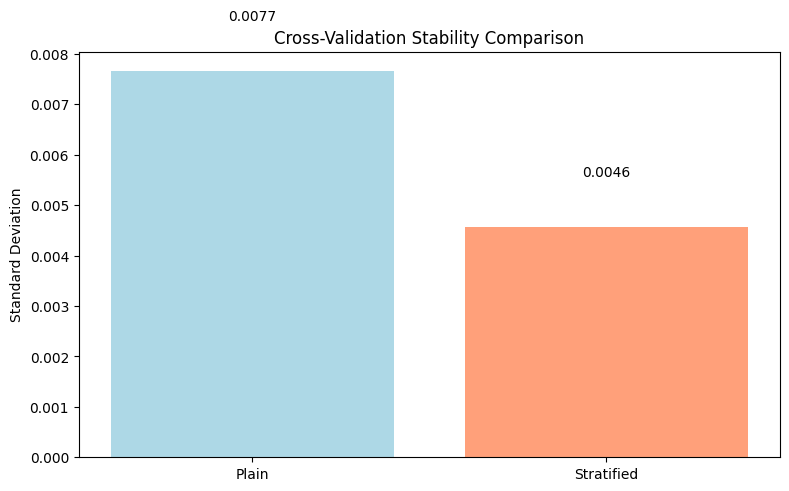

In [ ]:
plain, strat, p_val, conclusion = data_mining.q5()

print("Plain CV scores:     ", plain)
print("Stratified CV scores:", strat)
print("p-value:", p_val)
print("Conclusion:", conclusion)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([plain, strat], labels=['Plain','Stratified'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('5-fold CV Comparison (Distribution)')

# bar graph for mean accuracy
mean_scores = [np.mean(plain), np.mean(strat)]
axes[1].bar(['Plain', 'Stratified'], mean_scores, color=['blue', 'orange'])
axes[1].set_ylabel('Mean Accuracy')
axes[1].set_title('5-fold CV Comparison (Mean)')

for i, score in enumerate(mean_scores):
    axes[1].text(i, score + 0.01, f'{score:.3f}', ha='center')

plt.tight_layout()
plt.show()

# bar graph for standard deviation of accuracy
plt.figure(figsize=(8, 5))
std_scores = [np.std(plain), np.std(strat)]
plt.bar(['Plain', 'Stratified'], std_scores, color=['lightblue', 'lightsalmon'])
plt.ylabel('Standard Deviation')
plt.title('Cross-Validation Stability Comparison')

for i, std in enumerate(std_scores):
    plt.text(i, std + 0.001, f'{std:.4f}', ha='center')

plt.tight_layout()
plt.show()

We can conclude that: 

 - Stratification allowed for a lower variance

 - Mean accuracy was not significantly effected

## Q6: 2D Representation of All Samples

Here we: 

 - Perform unsupervised learning using LocallyLinearEmbedding

- Experiment with various neighbour settings



- Compute trustworthiness to indicate to what extent the local structure is retained.


Completed n_neighbors=40, trustworthiness=0.8461
Completed n_neighbors=80, trustworthiness=0.8531
Completed n_neighbors=120, trustworthiness=0.8622
Completed n_neighbors=160, trustworthiness=0.8642
Completed n_neighbors=200, trustworthiness=0.8602


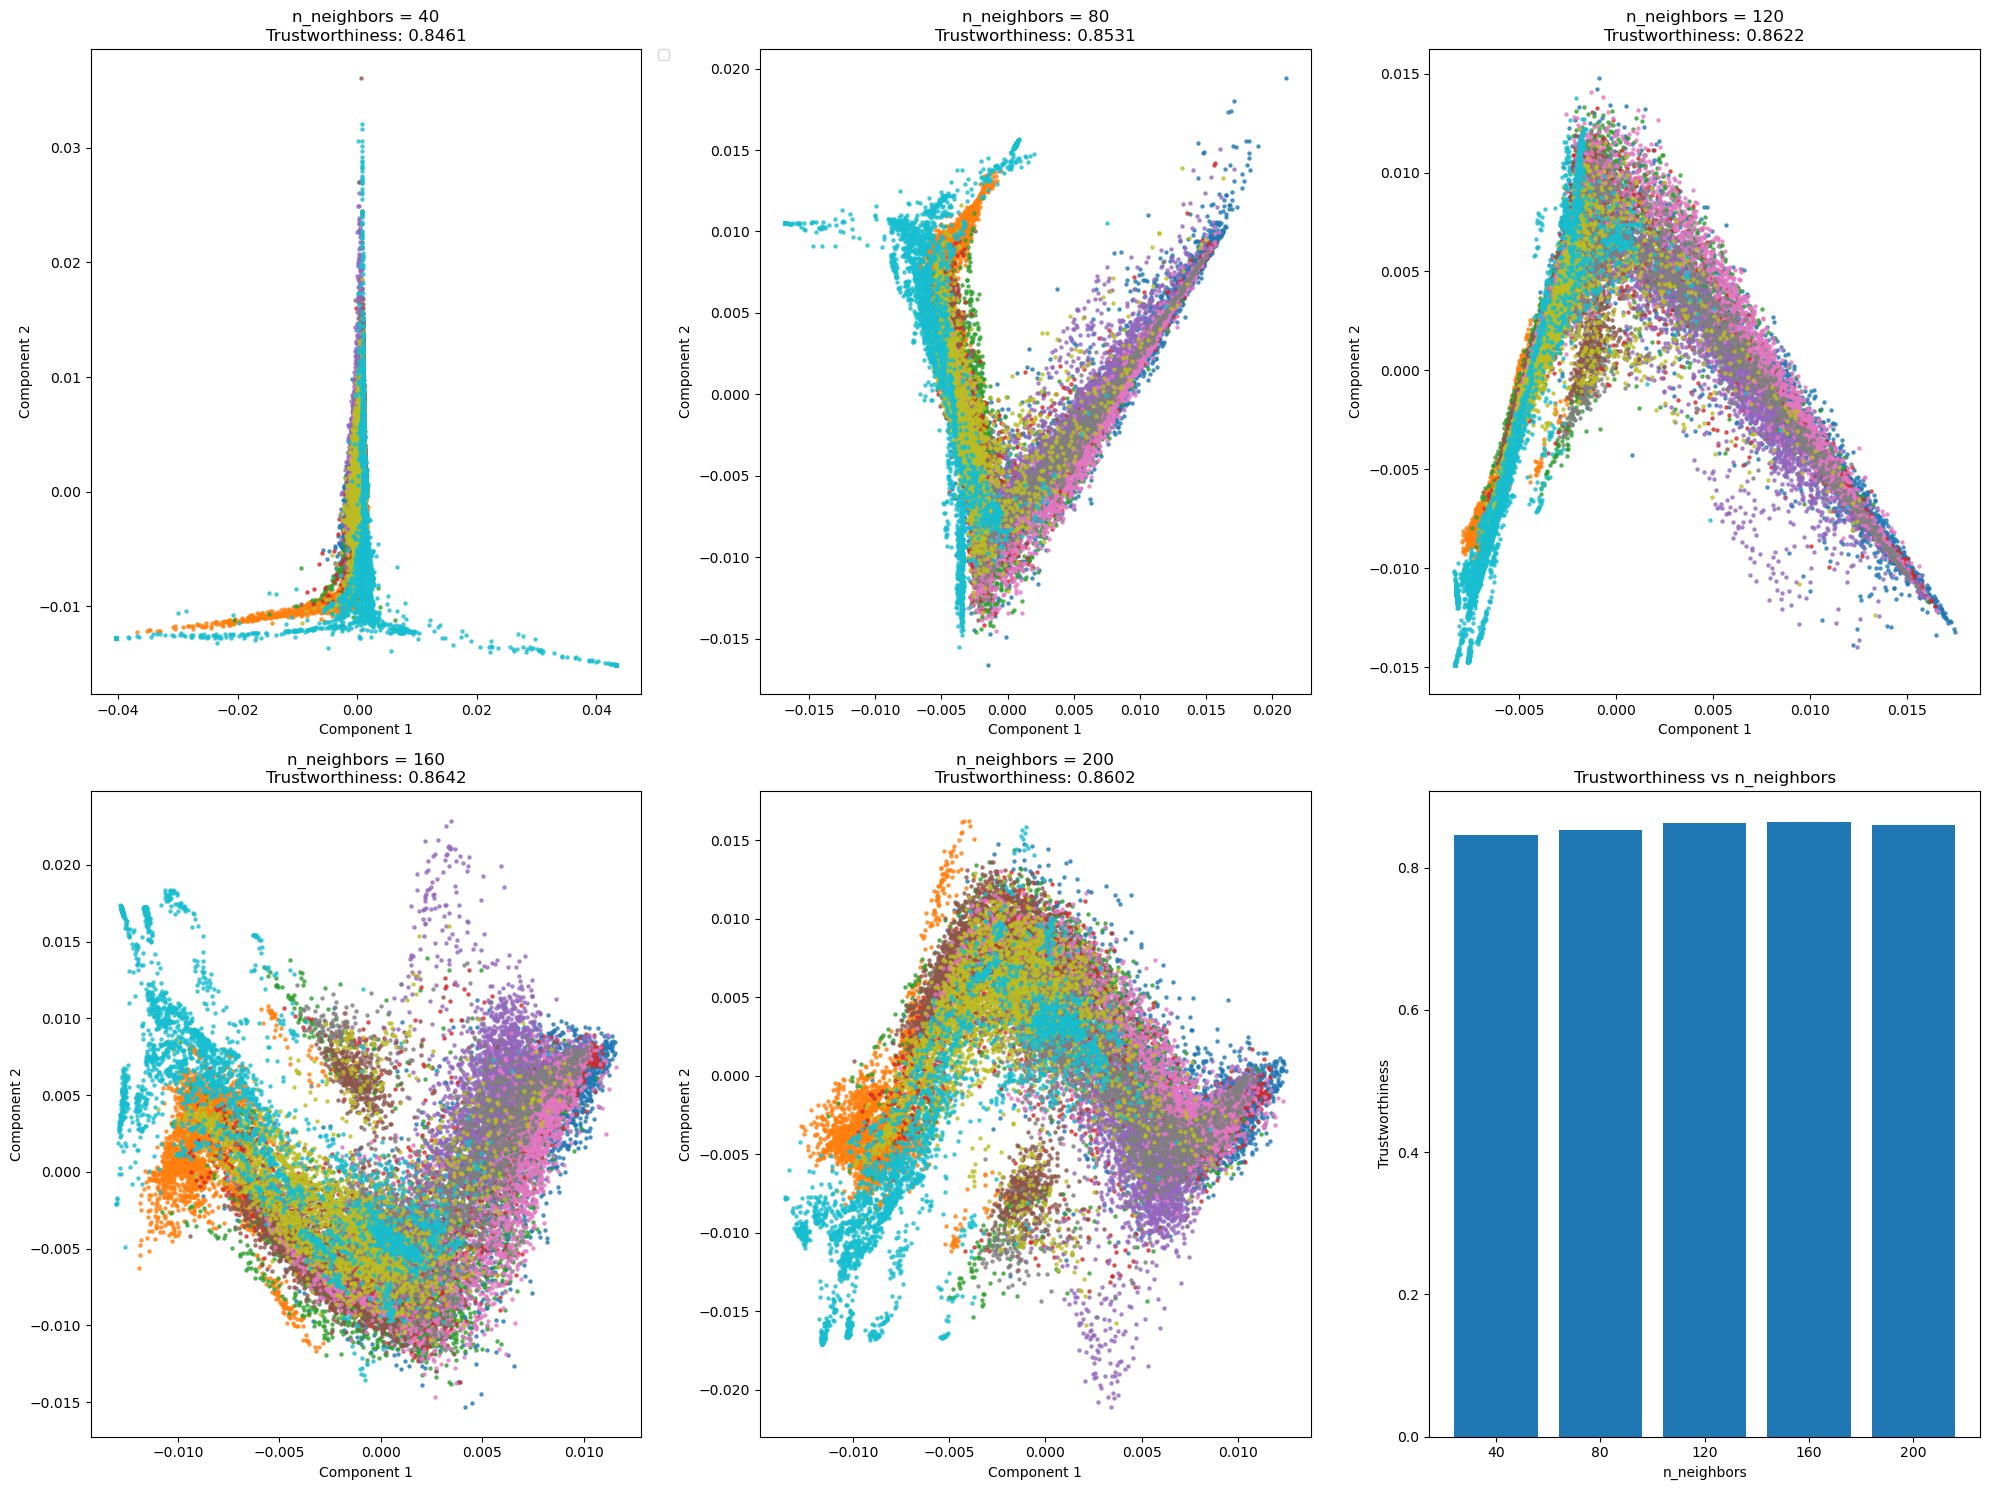

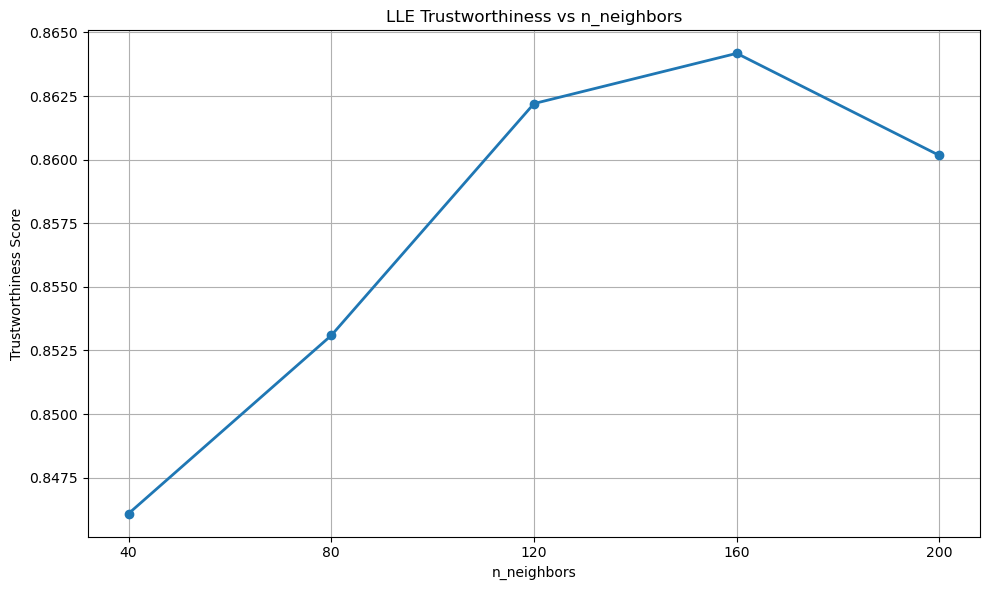

In [ ]:
q6_results = data_mining.q6()

n_neighbors_values = q6_results['n_neighbors_values']
embeddings = q6_results['embeddings']
trust_scores = q6_results['trustworthiness']

plt.figure(figsize=(20, 15))

for i, n_neighbors in enumerate(n_neighbors_values):
    plt.subplot(2, 3, i+1)
    embedding = embeddings[n_neighbors]
    trust = trust_scores[n_neighbors]
    
    for label in np.unique(data_mining.y):
        mask = (data_mining.y == label)
        plt.scatter(embedding[mask, 0], embedding[mask, 1], 
                    s=5, alpha=0.7, label=label if i == 0 else "")
    
    plt.title(f"n_neighbors = {n_neighbors}\nTrustworthiness: {trust:.4f}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")

handles, labels = plt.gca().get_legend_handles_labels()
plt.subplot(2, 3, 1).legend(handles, labels, loc='upper right', 
                           bbox_to_anchor=(1.05, 1), borderaxespad=0)

plt.subplot(2, 3, 6)
plt.bar(range(len(n_neighbors_values)), 
        [trust_scores[n] for n in n_neighbors_values],
        tick_label=[str(n) for n in n_neighbors_values])
plt.xlabel("n_neighbors")
plt.ylabel("Trustworthiness")
plt.title("Trustworthiness vs n_neighbors")

plt.tight_layout()
plt.savefig('lle_comparison.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(n_neighbors_values, [trust_scores[n] for n in n_neighbors_values], 'o-', linewidth=2)
plt.xlabel("n_neighbors")
plt.ylabel("Trustworthiness Score")
plt.title("LLE Trustworthiness vs n_neighbors")
plt.grid(True)
plt.xticks(n_neighbors_values)
plt.tight_layout()
plt.savefig('trustworthiness_comparison.png')
plt.show()

We can conclude that:

 - On the LLE Projection for different neighbour amounts. There is increasing seperation for larger neighborhoods

 - 160 neighbors seems to be optimal due to the seperateness and trustworthiness